In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# daisy.jpg is in a1images
IMG_DIR  = os.path.normpath(os.path.join(os.getcwd(), '..', 'question', 'a1images'))
SAVE_DIR = os.path.join(os.getcwd(), 'outputs')
os.makedirs(SAVE_DIR, exist_ok=True)

In [2]:
# homomorphic filter: log -> FFT -> multiply by H -> IFFT -> exp
# H is a highpass-ish shape: gamma_l suppresses low freq (illumination),
# gamma_h boosts high freq (reflectance) — sigma controls the transition
# +1.0 before log so we never hit log(0)
def homomorphic_filter(img_gray, sigma, gamma_l=0.5, gamma_h=2.0):
    img_f  = img_gray.astype(np.float64) + 1.0
    log_im = np.log(img_f)

    F = np.fft.fft2(log_im)
    F = np.fft.fftshift(F)

    rows, cols = img_gray.shape
    cy, cx = rows // 2, cols // 2
    y, x   = np.ogrid[-cy:rows - cy, -cx:cols - cx]
    D2     = x**2 + y**2

    H = (gamma_h - gamma_l) * (1 - np.exp(-D2 / (2 * sigma**2))) + gamma_l

    filtered = np.fft.ifft2(np.fft.ifftshift(F * H)).real
    out      = np.exp(filtered) - 1
    out      = np.clip(out, 0, 255).astype(np.uint8)
    return out

In [3]:
# load daisy, convert to grayscale, then run the filter with sigma=30
# sigma=30 gives a gradual low-to-high transition across the frequency plane
img    = cv2.imread(os.path.join(IMG_DIR, 'daisy.jpg'))
gray   = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
result = homomorphic_filter(gray, sigma=30)

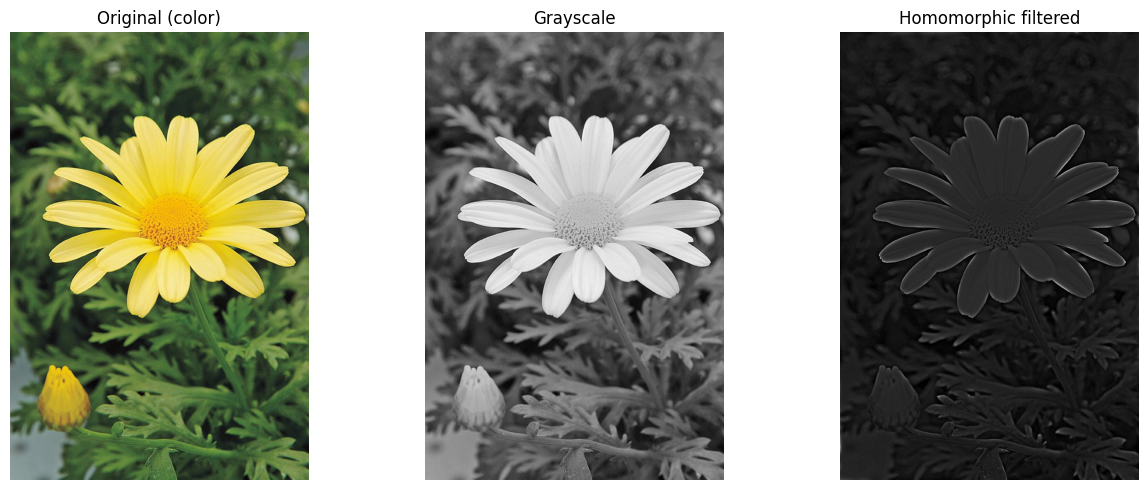

In [4]:
# three-way plot: colour original, grayscale, and filtered result
# the filtered version should have more even lighting and sharper details
fig, axes = plt.subplots(1, 3, figsize=(13, 5))

axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original (color)')
axes[0].axis('off')

axes[1].imshow(gray, cmap='gray')
axes[1].set_title('Grayscale')
axes[1].axis('off')

axes[2].imshow(result, cmap='gray')
axes[2].set_title('Homomorphic filtered')
axes[2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'q12_homomorphic.png'), dpi=150)
plt.show()